In [1]:
import operator
from typing import Annotated,TypedDict
from langchain_tavily import TavilySearch
from langchain_community.document_loaders import WikipediaLoader
from langchain_core.messages import HumanMessage,SystemMessage
from langgraph.graph import StateGraph,END,START


In [2]:
from langchain_groq import ChatGroq
llm=ChatGroq(model="Gemma2-9b-It")

In [3]:
llm.invoke("hello")

AIMessage(content='Hello! How can I help you today? 😄\n', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 13, 'prompt_tokens': 11, 'total_tokens': 24, 'completion_time': 0.023636364, 'prompt_time': 0.001919968, 'queue_time': 0.254395232, 'total_time': 0.025556332}, 'model_name': 'Gemma2-9b-It', 'system_fingerprint': 'fp_10c08bf97d', 'finish_reason': 'stop', 'logprobs': None}, id='run--b53a283a-ad09-4ca7-8fc9-a738328eee6d-0', usage_metadata={'input_tokens': 11, 'output_tokens': 13, 'total_tokens': 24})

In [28]:
class State(TypedDict):
    topic:str
    summary:str
    knowledge:Annotated[list,operator.add]
    #we are using operator.add here because when the data accumulated from both nodes
    #is extracted then both will try to update the state variable which may cause overriding of the
    #extracted data so to prevent that by appending we are using operator.add

In [40]:
def wiki_insights(state):
    articles = WikipediaLoader(query=state["topic"], load_max_docs=2).load()
    context = "\n----\n".join([doc.page_content for doc in articles if doc.page_content])
    return {"knowledge": [f"[wikipedia]\n{context}"] if context else []}


In [ ]:
def news_insights(state):
    search_tool = TavilySearch(max_results=3)
    results = search_tool.invoke(state["topic"])

    print("Raw Tavily results:", results)

    articles = []
    for doc in results:
        if isinstance(doc, dict):
            content = doc.get("content") or doc.get("body") or doc.get("text") or ""
            if content:
                articles.append(content)
        elif isinstance(doc, str):
            articles.append(doc)

    full_news = "\n----\n".join(articles)
    return {"knowledge": [f"[News]\n{full_news}"] if full_news else []}


In [41]:
def summarize_topic(state):
    if not state.get("knowledge"):
        return {"summary": "No usable information was retrieved to summarize."}

    context = "\n\n".join(state["knowledge"])
    prompt = f"Summarize the following information on the topic '{state['topic']}':\n\n{context}"

    reply = llm.invoke([
        SystemMessage(content="You are a tech analyst."),
        HumanMessage(content=prompt)
    ])

    return {"summary": reply}


In [43]:
builder=StateGraph(State)
builder.add_node("wiki_insights",wiki_insights)
builder.add_node("news_insights",news_insights)
builder.add_node("summarize_topic",summarize_topic)

builder.add_edge(START,"wiki_insights")
builder.add_edge(START,"news_insights")
builder.add_edge("wiki_insights","summarize_topic")
builder.add_edge("news_insights","summarize_topic")
builder.add_edge("summarize_topic",END)

bgraph=builder.compile()

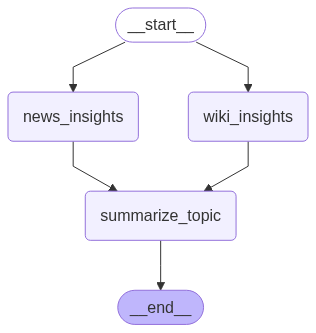

In [44]:
bgraph

In [45]:
from IPython.display import Markdown, display


In [25]:
%pip install wikipedia

Note: you may need to restart the kernel to use updated packages.


In [46]:
for step in bgraph.stream({"topic":"Apple vision pro launc"}):
    print(step)


display(Markdown(f"###Summary: {list(step.values())[0]['summary'].content}"))    

{'wiki_insights': {'knowledge': []}}
{'news_insights': {'knowledge': ['[News]\nquery\n----\nfollow_up_questions\n----\nanswer\n----\nimages\n----\nresults\n----\nresponse_time']}}
{'summarize_topic': {'summary': AIMessage(content='Please provide me with the information you\'d like me to summarize. I need the actual text content related to the "Apple Vision Pro launch" to give you a concise and accurate analysis. \n\nFor example, you can paste news articles, press releases, or any other relevant text about the launch. \n\n\nOnce you provide the content, I can help you with:\n\n* **A summary of the key features and specifications of the Apple Vision Pro.**\n* **Analysis of the target audience and potential market impact.**\n* **Comparison with competitors in the AR/VR space.**\n* **Discussion of the pricing and availability.**\n* **Identification of any notable announcements or reactions from the tech community.** \n\n\nLet me know what you have, and I\'ll get started! \n\n', additional_

###Summary: Please provide me with the information you'd like me to summarize. I need the actual text content related to the "Apple Vision Pro launch" to give you a concise and accurate analysis. 

For example, you can paste news articles, press releases, or any other relevant text about the launch. 


Once you provide the content, I can help you with:

* **A summary of the key features and specifications of the Apple Vision Pro.**
* **Analysis of the target audience and potential market impact.**
* **Comparison with competitors in the AR/VR space.**
* **Discussion of the pricing and availability.**
* **Identification of any notable announcements or reactions from the tech community.** 


Let me know what you have, and I'll get started! 



In [47]:
tool=TavilySearch()

In [48]:
tool.invoke("india gate")

{'query': 'india gate',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'title': 'India Gate - Wikipedia',
   'url': 'https://en.wikipedia.org/wiki/India_Gate',
   'content': 'India Gate is a monument to the soldiers of the Indian Army who died in World War I and the Third Anglo-Afghan War. It was designed by Sir Edwin Lutyens and has the names of 13,300 servicemen inscribed on it.',
   'score': 0.93468803,
   'raw_content': None},
  {'title': 'India Gate | Description, History, & Facts | Britannica',
   'url': 'https://www.britannica.com/topic/India-Gate',
   'content': 'India Gate, monumental sandstone arch in New Delhi, dedicated to the troops of British India who died in wars fought between 1914 and 1919. India Gate, which is located at the eastern end of the Rajpath (formerly called the Kingsway), is about 138 feet (42 metres) in height.',
   'score': 0.89166987,
   'raw_content': None},
  {'title': 'India Gate - History and Facts | History Hit',
   'ur